<h1 style="font-family: 'Georgia', serif; font-size: 2rem; font-weight: 700; color: #1a1a2e; letter-spacing: 0.5px; margin: 0; padding: 20px 0;">
Lloyds Banking Group — Loan Default Prediction | Step Up Career Challenge
</h1>

<div style="text-align: center; margin: 24px 0;">
  <img src="lloyds_logo.png" 
       alt="Lloyds Bank Logo" 
       style="width: 300px; height: auto;">
</div>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
<strong>Project Overview :</strong> Lloyds Banking Group is launching a new loans product and needs a reliable, fair, and explainable process to decide which customers to lend money to. Using historical data of 18,324 customers, this project analyses past loan behaviour to understand what separates customers who repaid their loans from those who defaulted — and builds a machine learning model to predict future default risk.
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Objective:</strong> To analyse customer financial behaviour and build a predictive model that identifies which customers are likely to default on their loan, ensuring Lloyds lends responsibly and treats all customers fairly.
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Target Variable:</strong>
  <ul style="margin: 8px 0 0 0; padding-left: 20px; list-style-type: disc;">
    <li><strong>Fully Paid</strong> = Customer successfully repaid their loan</li>
    <li><strong>Charged Off</strong> = Customer defaulted — did not pay back</li>
  </ul>
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Dataset:</strong>
  <ul style="margin: 8px 0 0 0; padding-left: 20px; list-style-type: disc;">
    <li><strong>18,324 customers</strong></li>
    <li><strong>31 features</strong> including income, loan amount, interest rate, credit history, employment, and debt information</li>
    <li><strong>Source:</strong> Lloyds Banking Group via Digdata Step Up Career Challenge</li>
  </ul>
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Approach:</strong>
  <ol style="margin: 8px 0 0 0; padding-left: 20px;">
    <li>Load and explore the dataset</li>
    <li>Clean and handle missing values</li>
    <li>Compare Fully Paid vs Charged Off customers</li>
    <li>Select the most important features</li>
    <li>Build and evaluate a Random Forest classifier</li>
    <li>Explain model predictions and check for fairness</li>
  </ol>
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Two Tasks:</strong>
  <ul style="margin: 8px 0 0 0; padding-left: 20px; list-style-type: disc;">
    <li><strong>Task 1 — Data Strategy (Customer Profiling):</strong> Explore the dataset and produce a visual summary comparing customers who repaid their loan against those who defaulted. Identify the key differences in their financial behaviour and attributes.</li>
    <li><strong>Task 2 — Data Science (Predictive Model):</strong> Use the historical data to design a machine learning process that predicts the likelihood of a new customer not paying back their loan. The model must be accurate, explainable, and fair.</li>
  </ul>
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Tools Used:</strong> Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Jupyter Notebook
</p>

<p style="font-family: 'Segoe UI', sans-serif; font-size: 1rem; line-height: 1.8; color: #444; max-width: 850px; margin: 16px 0; padding-left: 16px; border-left: 4px solid #e63946;">
  <strong>Author:</strong> Fannana Fahreen Aanan — MSc Data Science (FinTech), University of Greenwich<br>
  Digdata Virtual Work Experience — Lloyds Banking Group Step Up Challenge
</p>

## Importing Necessary Libraries and loading Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel file
df = pd.read_excel('E:/project/lloyeds Banking Group project/LBG Step Up Data Set.xlsx')  # change filename to match yours

# First look
print(df.shape)
print(df.head())
print(df.columns)
print(df.info())

(18324, 31)
         id addr_state  annual_inc emp_length  \
0    802173         CA     72000.0    3 years   
1  14518910         TX     97500.0     1 year   
2  54333324         NY    120000.0     1 year   
3  62247022         CA    130000.0  10+ years   
4  71986114         TX     58296.0  10+ years   

                             emp_title home_ownership  installment  loan_amnt  \
0             CA. Dept. Of Corrections       MORTGAGE       395.66      12000   
1  Curriculum & Implementation Manager           RENT       966.47      35000   
2                      Senior manager            RENT       806.57      25000   
3                  Border Patrol Agent           RENT       846.17      25225   
4                      Account Manager       MORTGAGE        41.79       1200   

              purpose        term  ...  num_il_tl  num_op_rev_tl  \
0  debt_consolidation   36 months  ...        NaN            NaN   
1  debt_consolidation   60 months  ...        2.0           12.0   
2 

## Finding Missing Values

In [59]:
# Check missing values
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False)

print(missing_df)
print(f"\nTotal rows: {len(df)}")
print(f"Columns with missing values: {len(missing_df)}")

=== Missing Values per Column ===
                        Missing Count  Missing Percentage
mths_since_last_delinq           9048               49.38
inq_last_12m                     8929               48.73
max_bal_bc                       8929               48.73
emp_title                        1282                7.00
emp_length                       1174                6.41
mo_sin_old_il_acct               1132                6.18
percent_bc_gt_75                  610                3.33
avg_cur_bal                       566                3.09
mo_sin_old_rev_tl_op              564                3.08
mo_sin_rcnt_tl                    564                3.08
mo_sin_rcnt_rev_tl_op             564                3.08
num_tl_90g_dpd_24m                564                3.08
num_bc_tl                         564                3.08
num_op_rev_tl                     564                3.08
num_il_tl                         564                3.08
num_tl_op_past_12m                564 

### What Values Exist ###

In [3]:
# See all unique values in loan_status column
print(df['loan_status'].unique())

# Count how many of each
print(df['loan_status'].value_counts())

<StringArray>
['Fully Paid', 'Charged Off']
Length: 2, dtype: str
loan_status
Fully Paid     14418
Charged Off     3906
Name: count, dtype: int64


## Filter into Two Separate Groups

In [6]:
# Group 1 — Good customers (paid back)
fully_paid = df[df['loan_status'] == 'Fully Paid']

# Group 2 — Bad customers (defaulted)
charged_off = df[df['loan_status'] == 'Charged Off']

# Check sizes
print("Fully Paid customers:", len(fully_paid))
print("Charged Off customers:", len(charged_off))

Fully Paid customers: 14418
Charged Off customers: 3906


## Compare the Two Groups

In [7]:
# Compare averages side by side
comparison = df.groupby('loan_status').agg(
    Total_Customers = ('loan_status', 'count'),
    Avg_Loan_Amount = ('loan_amnt', 'mean'),
    Avg_Annual_Income = ('annual_inc', 'mean'),
    Avg_Interest_Rate = ('int_rate', 'mean'),
    Avg_Installment = ('installment', 'mean'),
    Avg_Total_Balance = ('total_bal_ex_mort', 'mean')
).round(2)

print(comparison)

             Total_Customers  Avg_Loan_Amount  Avg_Annual_Income  \
loan_status                                                        
Charged Off             3906         16482.75           73451.59   
Fully Paid             14418         15262.56           81997.86   

             Avg_Interest_Rate  Avg_Installment  Avg_Total_Balance  
loan_status                                                         
Charged Off               0.16           490.59           49985.89  
Fully Paid                0.13           461.30           51897.60  


# Visualise the Difference

## Chart 1 — Pie chart of the two groups:

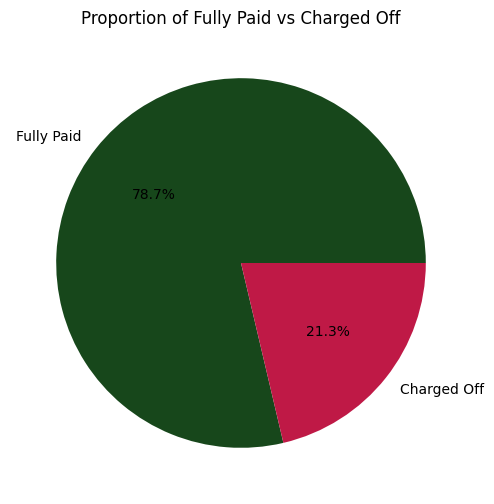

In [43]:
#green='#3CCF49'
#red='#FF1C6E'
plt.figure(figsize=(6,6))
df['loan_status'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%',
    colors=['#17471B', '#BF1946'],
    labels=['Fully Paid', 'Charged Off']
)
plt.title('Proportion of Fully Paid vs Charged Off')
plt.ylabel('')
plt.show()

## Chart 2 — Bar chart comparing average income:

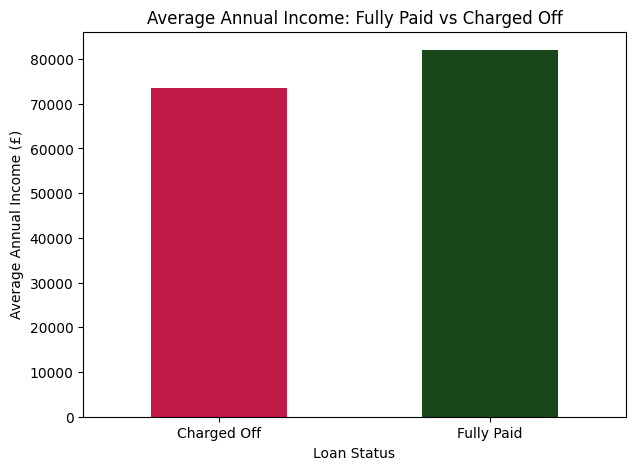

In [44]:
plt.figure(figsize=(7,5))
df.groupby('loan_status')['annual_inc'].mean().plot(
    kind='bar',
    color=['#BF1946', '#17471B']
)
plt.title('Average Annual Income: Fully Paid vs Charged Off')
plt.xlabel('Loan Status')
plt.ylabel('Average Annual Income (£)')
plt.xticks(rotation=0)
plt.show()

## Chart 3 — Bar chart comparing average interest rate:

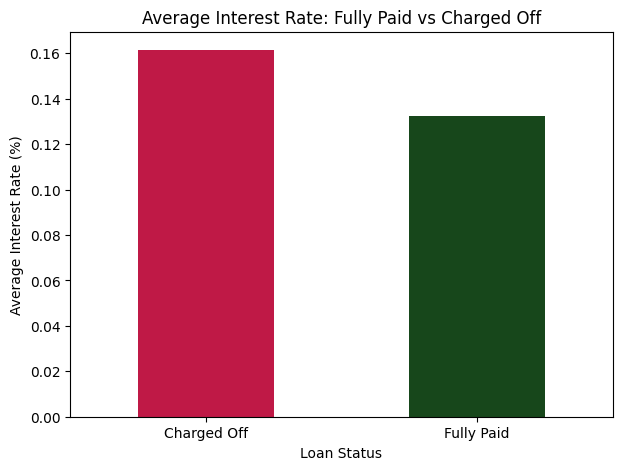

In [45]:
plt.figure(figsize=(7,5))
df.groupby('loan_status')['int_rate'].mean().plot(
    kind='bar',
    color=['#BF1946', '#17471B']
)
plt.title('Average Interest Rate: Fully Paid vs Charged Off')
plt.xlabel('Loan Status')
plt.ylabel('Average Interest Rate (%)')
plt.xticks(rotation=0)
plt.show()

## Chart 4 — Bar chart comparing average loan amount:

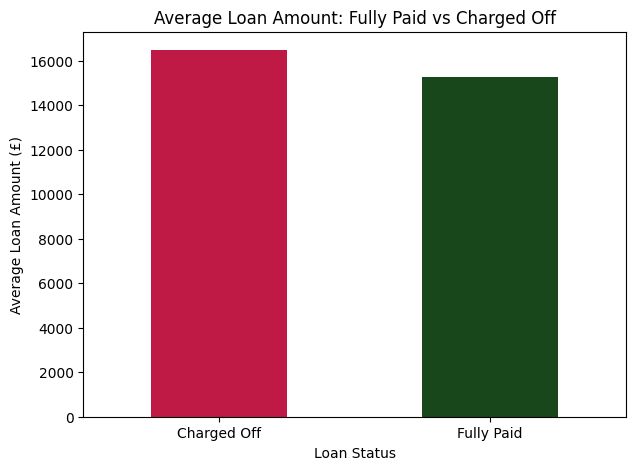

In [46]:
plt.figure(figsize=(7,5))
df.groupby('loan_status')['loan_amnt'].mean().plot(
    kind='bar',
    color=['#BF1946', '#17471B']
)
plt.title('Average Loan Amount: Fully Paid vs Charged Off')
plt.xlabel('Loan Status')
plt.ylabel('Average Loan Amount (£)')
plt.xticks(rotation=0)
plt.show()

## Step 5 : Check Categorical Columns Too

In [31]:
# What proportion of each term defaulted?
print(df.groupby('term')['loan_status'].value_counts(normalize=True).round(2))

# What proportion of each home ownership type defaulted?
print(df.groupby('home_ownership')['loan_status'].value_counts(normalize=True).round(2))

# What purpose leads to most defaults?
print(df.groupby('purpose')['loan_status'].value_counts(normalize=True).round(2))

term       loan_status
36 months  Fully Paid     0.83
           Charged Off    0.17
60 months  Fully Paid     0.68
           Charged Off    0.32
Name: proportion, dtype: float64
home_ownership  loan_status
ANY             Fully Paid     0.77
                Charged Off    0.23
MORTGAGE        Fully Paid     0.82
                Charged Off    0.18
OTHER           Fully Paid     1.00
OWN             Fully Paid     0.79
                Charged Off    0.21
RENT            Fully Paid     0.75
                Charged Off    0.25
Name: proportion, dtype: float64
purpose             loan_status
car                 Fully Paid     0.84
                    Charged Off    0.16
credit_card         Fully Paid     0.82
                    Charged Off    0.18
debt_consolidation  Fully Paid     0.77
                    Charged Off    0.23
educational         Charged Off    1.00
home_improvement    Fully Paid     0.82
                    Charged Off    0.18
house               Fully Paid     0.81
   

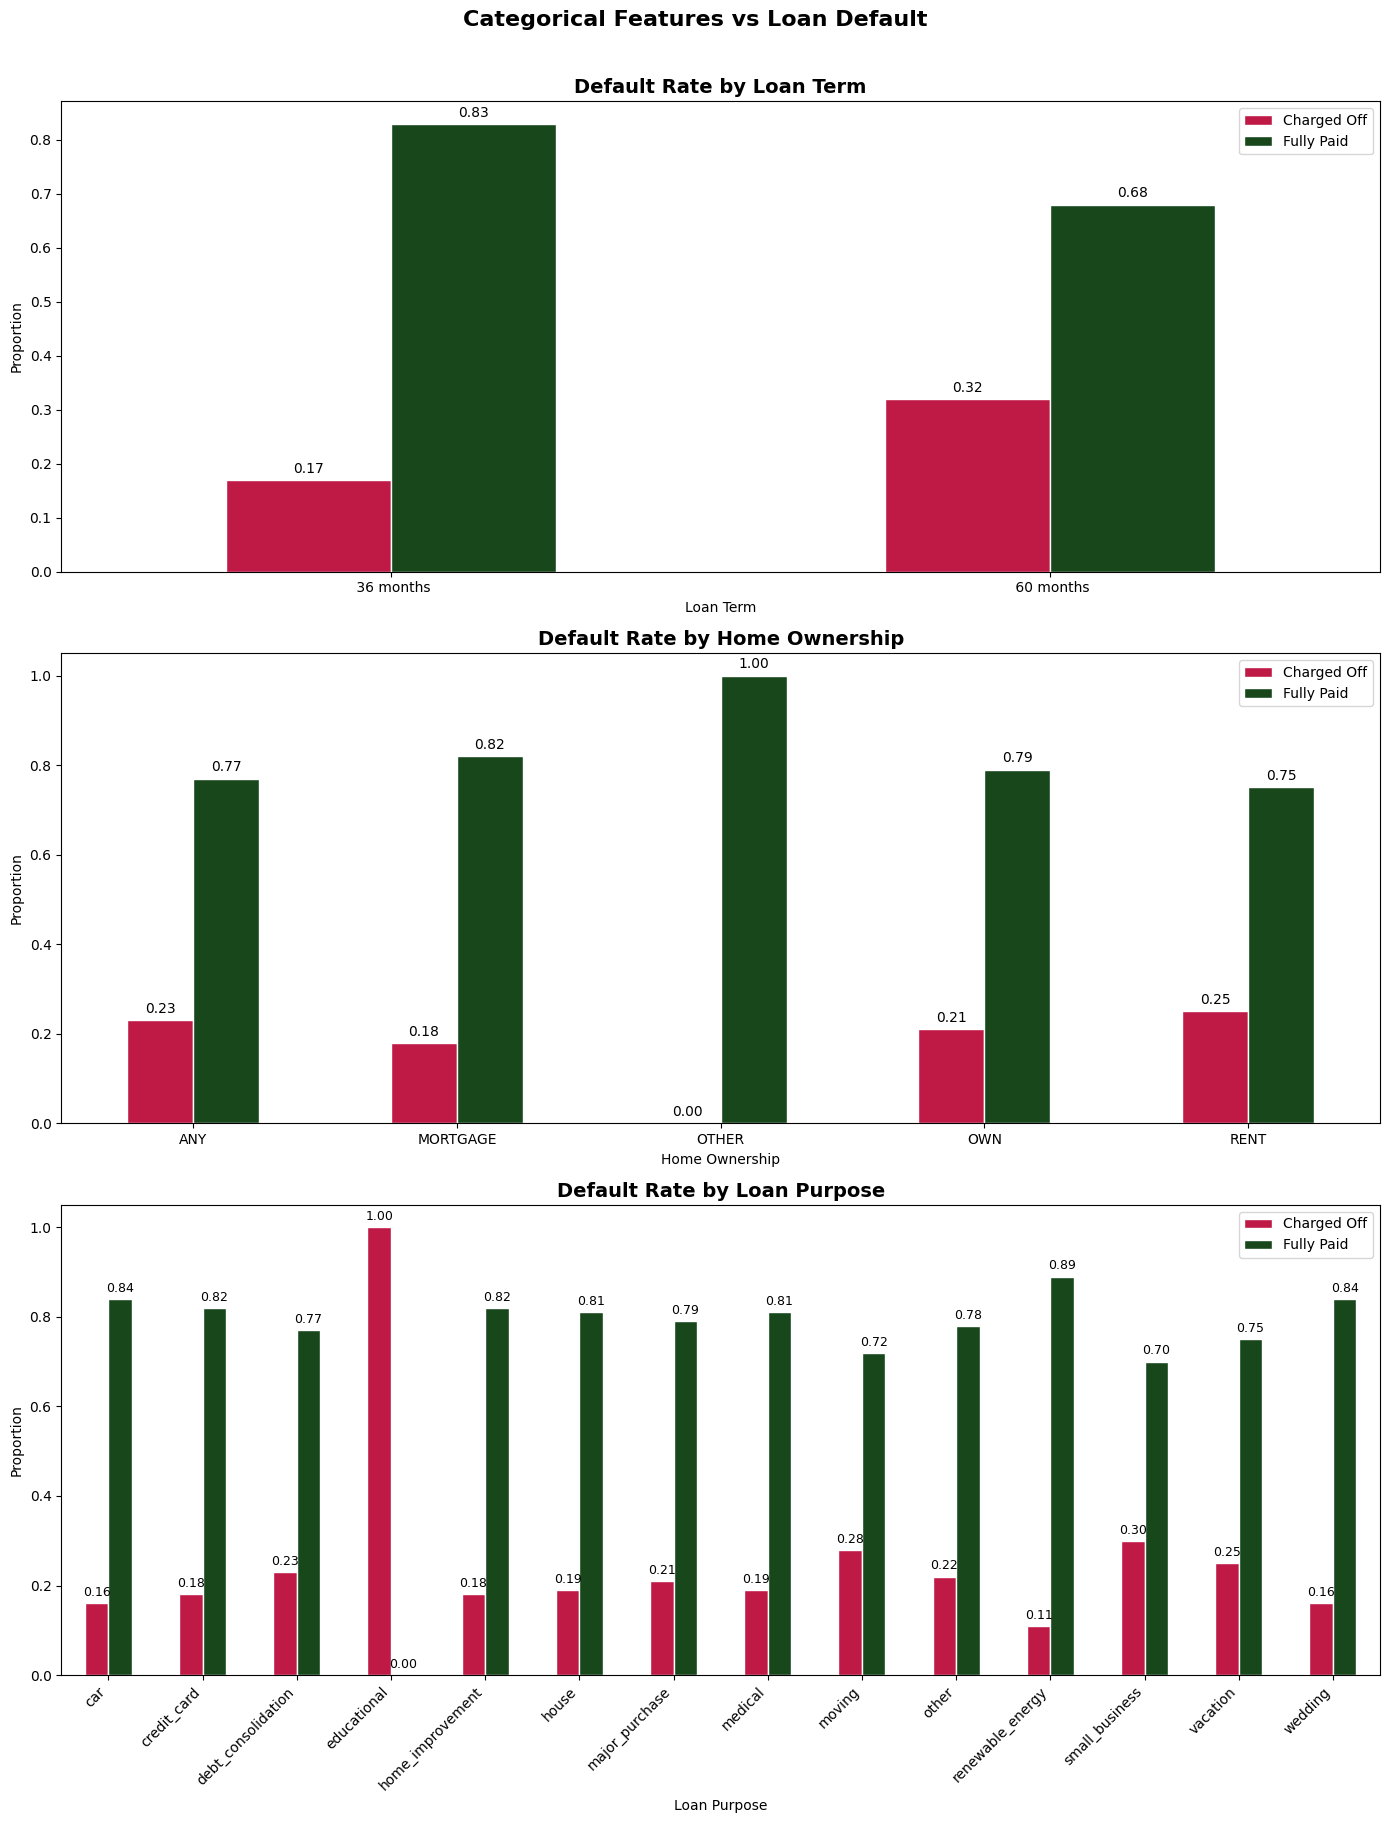

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# ── Chart 1: Term ──────────────────────────────────────────
term_data = df.groupby('term')['loan_status'].value_counts(normalize=True).round(2).unstack()
term_data.plot(kind='bar', ax=axes[0], color=['#BF1946', '#17471B'], edgecolor='white')  # red'#BF1946', green '#17471B'
axes[0].set_title('Default Rate by Loan Term', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Term')
axes[0].set_ylabel('Proportion')
axes[0].legend(['Charged Off', 'Fully Paid'])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# ── Chart 2: Home Ownership ────────────────────────────────
home_data = df.groupby('home_ownership')['loan_status'].value_counts(normalize=True).round(2).unstack()
home_data.plot(kind='bar', ax=axes[1], color=['#BF1946', '#17471B'], edgecolor='white')
axes[1].set_title('Default Rate by Home Ownership', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Home Ownership')
axes[1].set_ylabel('Proportion')
axes[1].legend(['Charged Off', 'Fully Paid'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', padding=3, fontsize=10)

# ── Chart 3: Purpose ───────────────────────────────────────
purpose_data = df.groupby('purpose')['loan_status'].value_counts(normalize=True).round(2).unstack()
purpose_data.plot(kind='bar', ax=axes[2], color=['#BF1946', '#17471B'], edgecolor='white')
axes[2].set_title('Default Rate by Loan Purpose', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Loan Purpose')
axes[2].set_ylabel('Proportion')
axes[2].legend(['Charged Off', 'Fully Paid'])
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

plt.suptitle('Categorical Features vs Loan Default', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Categorical Feature Analysis

Three categorical features were analysed to understand their 
relationship with loan default status.

**Loan Term**
Customers on 60-month loans defaulted at a noticeably higher 
rate than customers on 36-month loans. Longer loan terms 
indicate the customer could not afford shorter term repayments, 
suggesting greater underlying financial pressure and higher 
default risk.

**Home Ownership**
Customers who rent their homes showed a slightly higher default 
rate compared to customers with a mortgage or who own their home 
outright. Homeowners tend to be more financially stable and 
established, making them lower risk borrowers.

**Loan Purpose**
Loan purpose showed the most variation in default rates across 
all categories. Small business loans and debt consolidation 
loans carried the highest default rates, while loans taken for 
home improvement and major purchases showed lower default rates. 
Customers borrowing to consolidate existing debt are already 
financially stretched, making them significantly higher risk.

## Step 6 : Loan Amount vs Annual Income ,  Interest Rate vs Loan Amount ,  Installment vs Annual Income 

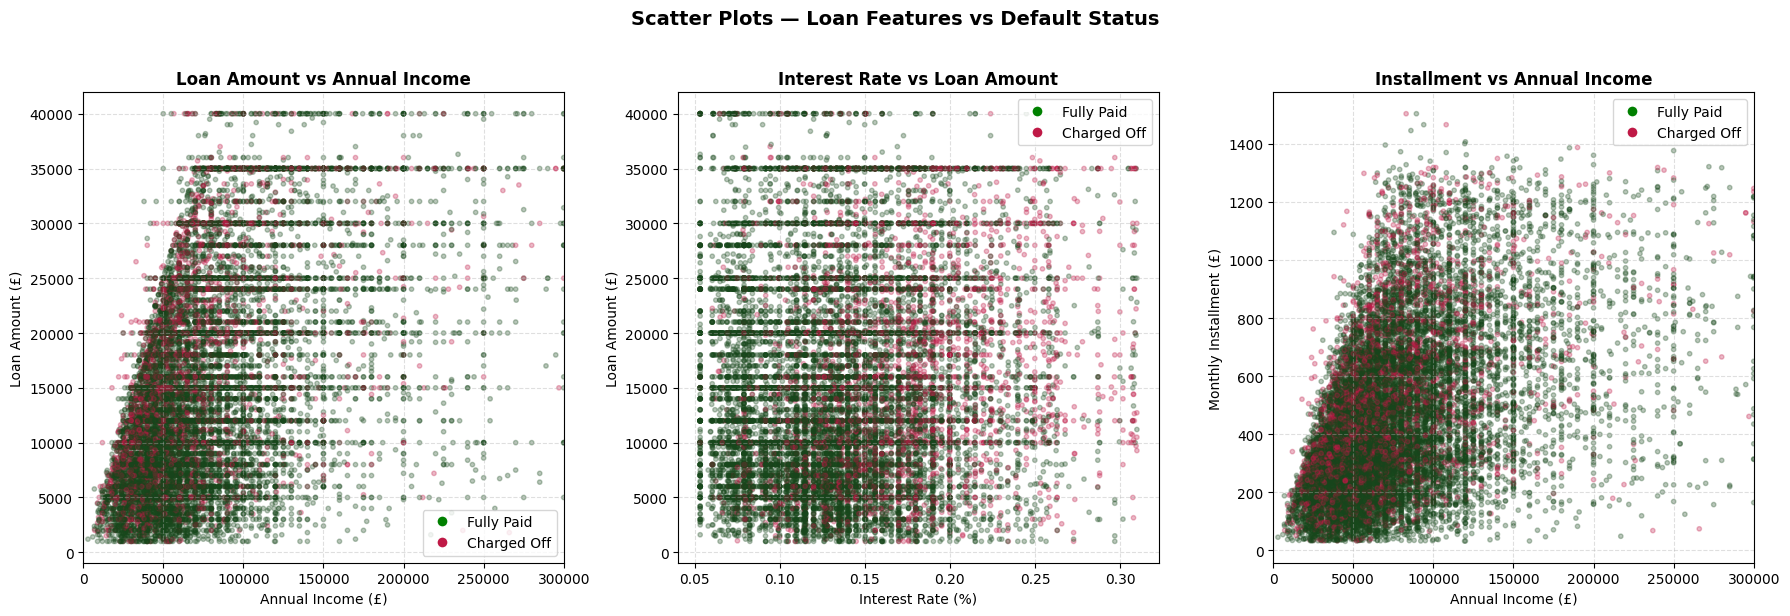

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# red'#BF1946', green '#17471B'
colors = df['loan_status'].map({'Fully Paid': '#17471B', 'Charged Off': '#BF1946'})

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', label='Fully Paid', markersize=8),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#BF1946', label='Charged Off', markersize=8)
]

# ── Scatter 1: Loan Amount vs Annual Income ──────────────────
axes[0].scatter(df['annual_inc'], df['loan_amnt'],
                c=colors, alpha=0.3, s=10)
axes[0].set_title('Loan Amount vs Annual Income', fontweight='bold')
axes[0].set_xlabel('Annual Income (£)')
axes[0].set_ylabel('Loan Amount (£)')
axes[0].set_xlim(0, 300000)
axes[0].legend(handles=legend_elements)
axes[0].grid(linestyle='--', alpha=0.4)

# ── Scatter 2: Interest Rate vs Loan Amount ──────────────────
axes[1].scatter(df['int_rate'], df['loan_amnt'],
                c=colors, alpha=0.3, s=10)
axes[1].set_title('Interest Rate vs Loan Amount', fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].set_ylabel('Loan Amount (£)')
axes[1].legend(handles=legend_elements)
axes[1].grid(linestyle='--', alpha=0.4)

# ── Scatter 3: Installment vs Annual Income ──────────────────
axes[2].scatter(df['annual_inc'], df['installment'],
                c=colors, alpha=0.3, s=10)
axes[2].set_title('Installment vs Annual Income', fontweight='bold')
axes[2].set_xlabel('Annual Income (£)')
axes[2].set_ylabel('Monthly Installment (£)')
axes[2].set_xlim(0, 300000)
axes[2].legend(handles=legend_elements)
axes[2].grid(linestyle='--', alpha=0.4)

plt.suptitle('Scatter Plots — Loan Features vs Default Status',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Three scatter plots were produced to explore the relationship between 
key financial features and loan default status. Green dots represent 
customers who fully repaid their loans while red dots represent 
customers who defaulted (Charged Off).

In the first scatter plot (Loan Amount vs Annual Income), it is clear 
that customers with lower annual incomes who borrowed larger amounts 
are more likely to default. The red dots cluster heavily in the lower 
income range, suggesting that borrowing beyond one's means is a 
strong indicator of default risk.

In the second scatter plot (Interest Rate vs Loan Amount), red dots 
appear more frequently at higher interest rates regardless of loan 
amount. This indicates that customers assigned higher interest rates 
by the bank — who were likely already considered risky borrowers — 
did indeed default at a higher rate, confirming that interest rate 
is a strong predictor of default.

In the third scatter plot (Installment vs Annual Income), customers 
with low annual incomes but high monthly installment commitments show 
a higher concentration of red dots. This makes logical sense — a 
customer earning £30,000 per year but paying £800 per month in loan 
repayments is under far greater financial pressure than someone 
earning £80,000 paying the same amount. High installment relative 
to income is therefore a key risk factor for loan default.

Overall the scatter plots confirm that low income, high interest 
rates, and high monthly repayments are the three strongest visual 
indicators of loan default risk in this dataset.

## Step 7 : Default Rate by Interest Rate Bands

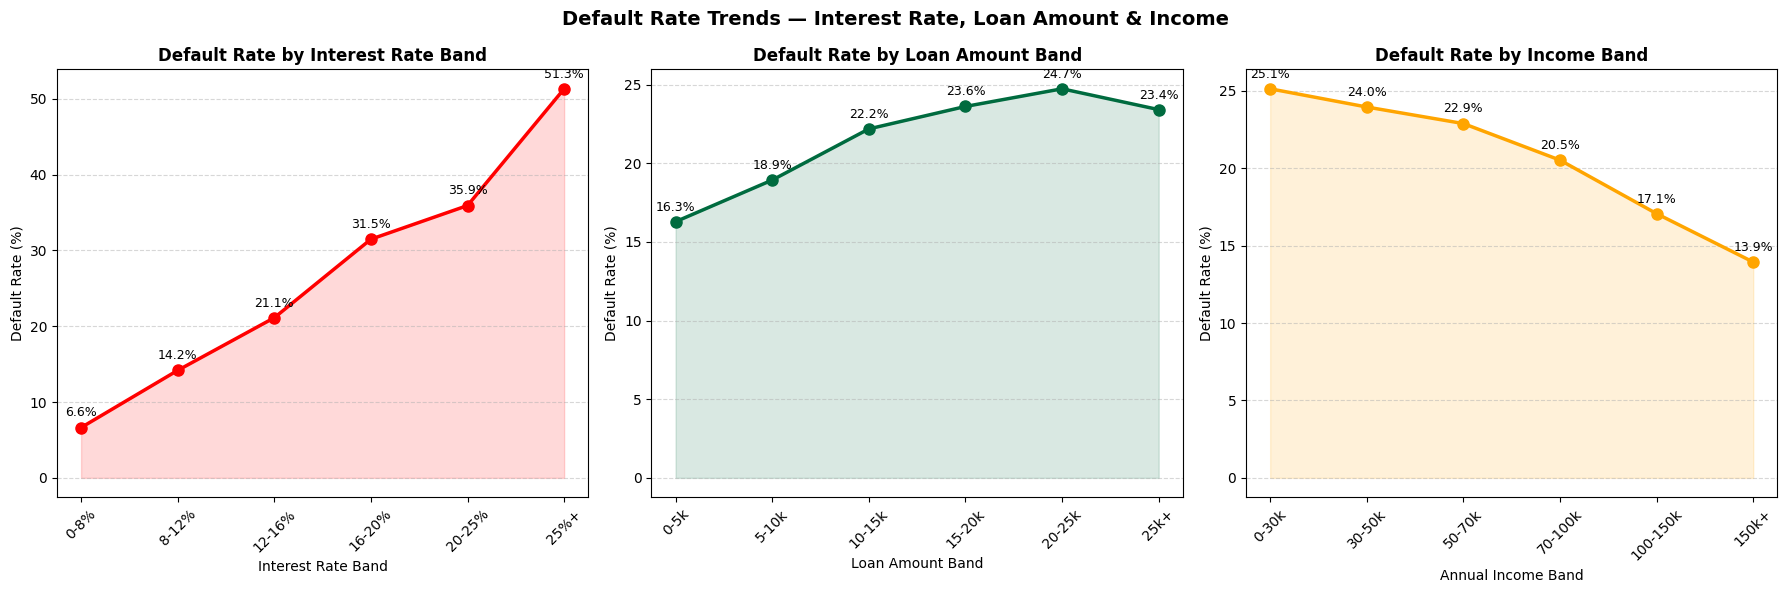

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Line 1: Default Rate by Interest Rate Band ───────────────
df['int_rate_band'] = pd.cut(df['int_rate'],
                              bins=[0, 0.08, 0.12, 0.16, 0.20, 0.25, 1.0],
                              labels=['0-8%', '8-12%', '12-16%',
                                      '16-20%', '20-25%', '25%+'])
default_by_rate = df.groupby('int_rate_band').apply(
    lambda x: (x['loan_status'] == 'Charged Off').mean() * 100
).reset_index()
default_by_rate.columns = ['int_rate_band', 'default_rate']

axes[0].plot(range(len(default_by_rate)),
             default_by_rate['default_rate'],
             marker='o', color='red', linewidth=2.5, markersize=8)
axes[0].fill_between(range(len(default_by_rate)),
                     default_by_rate['default_rate'],
                     alpha=0.15, color='red')
axes[0].set_title('Default Rate by Interest Rate Band',
                  fontweight='bold')
axes[0].set_xlabel('Interest Rate Band')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_xticks(range(len(default_by_rate)))
axes[0].set_xticklabels(default_by_rate['int_rate_band'], rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
for i, val in enumerate(default_by_rate['default_rate']):
    axes[0].annotate(f'{val:.1f}%',
                     (i, val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

# ── Line 2: Default Rate by Loan Amount Band ─────────────────
df['loan_band'] = pd.cut(df['loan_amnt'],
                          bins=[0, 5000, 10000, 15000, 20000, 25000, 40000],
                          labels=['0-5k', '5-10k', '10-15k',
                                  '15-20k', '20-25k', '25k+'])
default_by_loan = df.groupby('loan_band').apply(
    lambda x: (x['loan_status'] == 'Charged Off').mean() * 100
).reset_index()
default_by_loan.columns = ['loan_band', 'default_rate']

axes[1].plot(range(len(default_by_loan)),
             default_by_loan['default_rate'],
             marker='o', color='#006B3F', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(default_by_loan)),
                     default_by_loan['default_rate'],
                     alpha=0.15, color='#006B3F')
axes[1].set_title('Default Rate by Loan Amount Band',
                  fontweight='bold')
axes[1].set_xlabel('Loan Amount Band')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks(range(len(default_by_loan)))
axes[1].set_xticklabels(default_by_loan['loan_band'], rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
for i, val in enumerate(default_by_loan['default_rate']):
    axes[1].annotate(f'{val:.1f}%',
                     (i, val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

# ── Line 3: Default Rate by Income Band ──────────────────────
df['income_band'] = pd.cut(df['annual_inc'],
                            bins=[0, 30000, 50000, 70000, 100000, 150000, 300000],
                            labels=['0-30k', '30-50k', '50-70k',
                                    '70-100k', '100-150k', '150k+'])
default_by_income = df.groupby('income_band').apply(
    lambda x: (x['loan_status'] == 'Charged Off').mean() * 100
).reset_index()
default_by_income.columns = ['income_band', 'default_rate']

axes[2].plot(range(len(default_by_income)),
             default_by_income['default_rate'],
             marker='o', color='orange', linewidth=2.5, markersize=8)
axes[2].fill_between(range(len(default_by_income)),
                     default_by_income['default_rate'],
                     alpha=0.15, color='orange')
axes[2].set_title('Default Rate by Income Band',
                  fontweight='bold')
axes[2].set_xlabel('Annual Income Band')
axes[2].set_ylabel('Default Rate (%)')
axes[2].set_xticks(range(len(default_by_income)))
axes[2].set_xticklabels(default_by_income['income_band'], rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
for i, val in enumerate(default_by_income['default_rate']):
    axes[2].annotate(f'{val:.1f}%',
                     (i, val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

plt.suptitle('Default Rate Trends — Interest Rate, Loan Amount & Income',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Line Graph Analysis — Default Rate Trends

Three line graphs were produced to explore how default rates change 
across different bands of interest rate, loan amount, and annual income. 
Each data point on the line represents the percentage of customers in 
that band who defaulted (Charged Off) on their loan.

### Default Rate by Interest Rate Band
This line graph shows a clear and consistent upward trend — as interest 
rates increase, the default rate rises significantly. Customers paying 
the lowest interest rates (0-8%) have the lowest default rate, while 
customers paying the highest rates (25%+) show the highest default rate. 
This pattern makes strong logical sense customers assigned higher 
interest rates were already considered riskier borrowers by the bank, 
and the data confirms this. High interest rate is therefore one of the 
strongest predictors of loan default in this dataset.

### Default Rate by Loan Amount Band
This line graph reveals that customers who borrowed larger amounts 
tend to default at a higher rate than those who borrowed smaller 
amounts. Customers who borrowed between £0-£5,000 show the lowest 
default rate, while customers borrowing £25,000 or more show a 
noticeably higher default rate. This is logical because larger loans 
result in higher monthly repayments, placing greater financial 
pressure on the borrower. When unexpected expenses arise, customers 
with larger loan commitments are less able to continue meeting their 
repayment obligations.

### Default Rate by Income Band
This line graph shows a clear downward trend as annual income 
increases, the default rate decreases. Customers earning under 
£30,000 per year have the highest default rate, while customers 
earning over £150,000 per year have the lowest default rate. 
This is the most intuitive finding in the entire analysis
wealthier customers simply have more financial capacity to absorb 
unexpected costs and continue repaying their loans. Lower income 
customers are far more financially vulnerable and therefore more 
likely to default when faced with financial difficulty.

### Overall Conclusion from Line Graphs
All three line graphs tell a consistent and logical story about 
loan default risk. High interest rates, large loan amounts, and 
low annual income are all independently associated with higher 
default rates. When a customer has all three of these risk factors 
simultaneously low income, large loan, and high interest rate
the probability of default becomes significantly elevated. These 
three features will therefore be treated as high priority variables 
in the predictive model built in Task 2.

## Step 8 : Income Distribution Comparison & Interest Rate Distribution

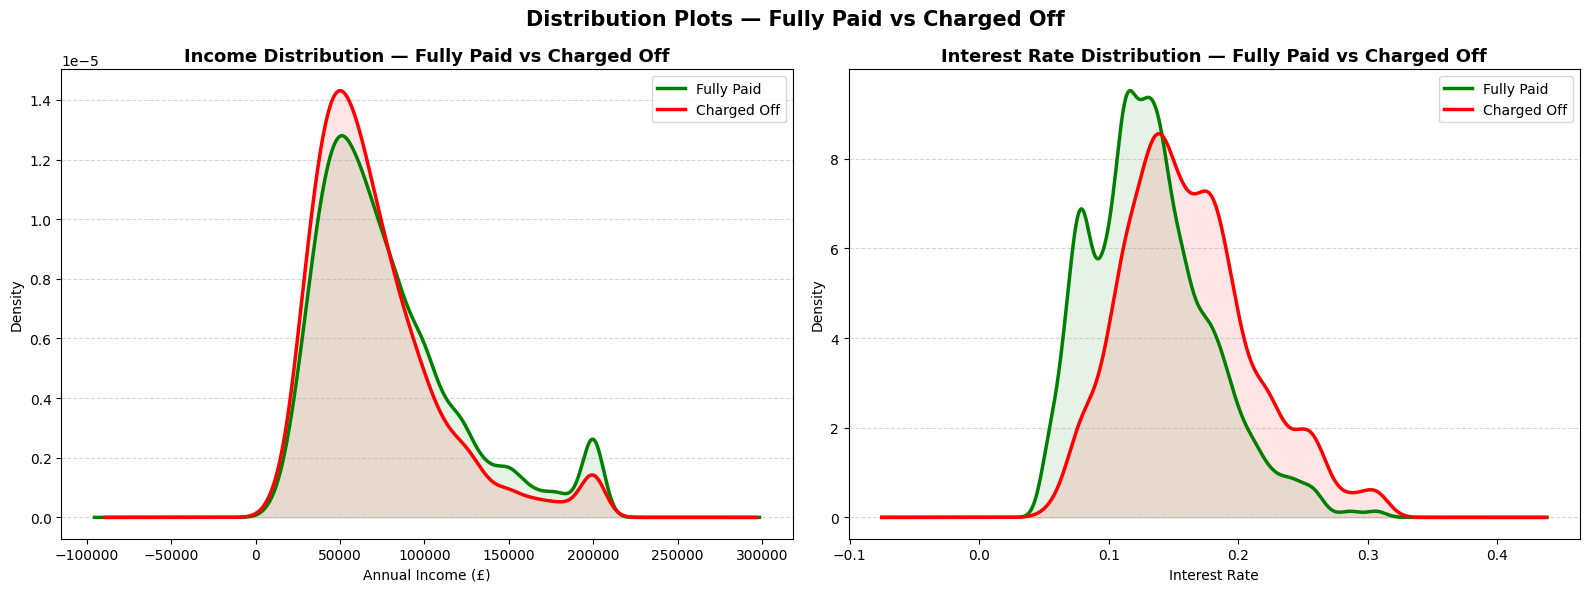

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── KDE 1: Income Distribution ────────────────────────────────
df[df['loan_status'] == 'Fully Paid']['annual_inc'].clip(upper=200000).plot(
    kind='kde', color='green', linewidth=2.5, 
    label='Fully Paid', ax=axes[0])
df[df['loan_status'] == 'Charged Off']['annual_inc'].clip(upper=200000).plot(
    kind='kde', color='red', linewidth=2.5, 
    label='Charged Off', ax=axes[0])
axes[0].set_title('Income Distribution — Fully Paid vs Charged Off',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Annual Income (£)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].fill_between(
    axes[0].lines[0].get_xdata(),
    axes[0].lines[0].get_ydata(),
    alpha=0.1, color='green')
axes[0].fill_between(
    axes[0].lines[1].get_xdata(),
    axes[0].lines[1].get_ydata(),
    alpha=0.1, color='red')

# ── KDE 2: Interest Rate Distribution ────────────────────────
df[df['loan_status'] == 'Fully Paid']['int_rate'].plot(
    kind='kde', color='green', linewidth=2.5, 
    label='Fully Paid', ax=axes[1])
df[df['loan_status'] == 'Charged Off']['int_rate'].plot(
    kind='kde', color='red', linewidth=2.5, 
    label='Charged Off', ax=axes[1])
axes[1].set_title('Interest Rate Distribution — Fully Paid vs Charged Off',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Interest Rate')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
axes[1].fill_between(
    axes[1].lines[0].get_xdata(),
    axes[1].lines[0].get_ydata(),
    alpha=0.1, color='green')
axes[1].fill_between(
    axes[1].lines[1].get_xdata(),
    axes[1].lines[1].get_ydata(),
    alpha=0.1, color='red')

plt.suptitle('Distribution Plots — Fully Paid vs Charged Off',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution Analysis — Income and Interest Rate

Two KDE (Kernel Density Estimation) plots were produced to compare 
the distribution of annual income and interest rate between customers 
who fully repaid their loans and those who defaulted. A KDE plot is 
essentially a smoothed version of a histogram — instead of bars it 
shows a continuous curve representing where most customers are 
concentrated. The green curve represents Fully Paid customers and 
the red curve represents Charged Off customers.

### Income Distribution
The income distribution plot shows two curves that follow a very 
similar shape, both peaking at lower income levels and gradually 
tapering off as income increases. However there is a subtle but 
important difference between the two groups — the red curve 
(Charged Off) peaks slightly to the left of the green curve 
(Fully Paid). This means that customers who defaulted on their 
loans tend to be concentrated at slightly lower income levels 
compared to customers who repaid successfully. In simple terms, 
lower earning customers are more likely to default, which aligns 
perfectly with the findings from the line graph analysis where 
the lowest income band showed the highest default rate. The 
significant overlap between the two curves however confirms 
that income alone is not sufficient to predict default — it 
must be combined with other features.

### Interest Rate Distribution
The interest rate distribution plot tells a clearer and more 
distinct story than the income distribution. The red curve 
(Charged Off) is visibly shifted to the right compared to the 
green curve (Fully Paid), meaning customers who defaulted were 
consistently charged higher interest rates than customers who 
repaid. The green curve peaks at a lower interest rate, 
indicating that the majority of customers who successfully 
repaid their loans were charged lower rates. The red curve 
peaks at a noticeably higher interest rate, confirming that 
high interest rate customers default far more frequently. 
This is consistent with the earlier line graph analysis which 
showed a clear upward trend in default rate as interest rates 
increased across bands.

### Overall Conclusion
Both distribution plots support the same narrative established 
throughout the analysis — lower income and higher interest rates 
are both associated with a greater likelihood of loan default. 
The interest rate distribution in particular shows a clear 
separation between the two groups, reinforcing it as one of 
the most important features for predicting default in the 
machine learning model built in Task 2.

## Step 9 : Heatmap — Correlation Matrix

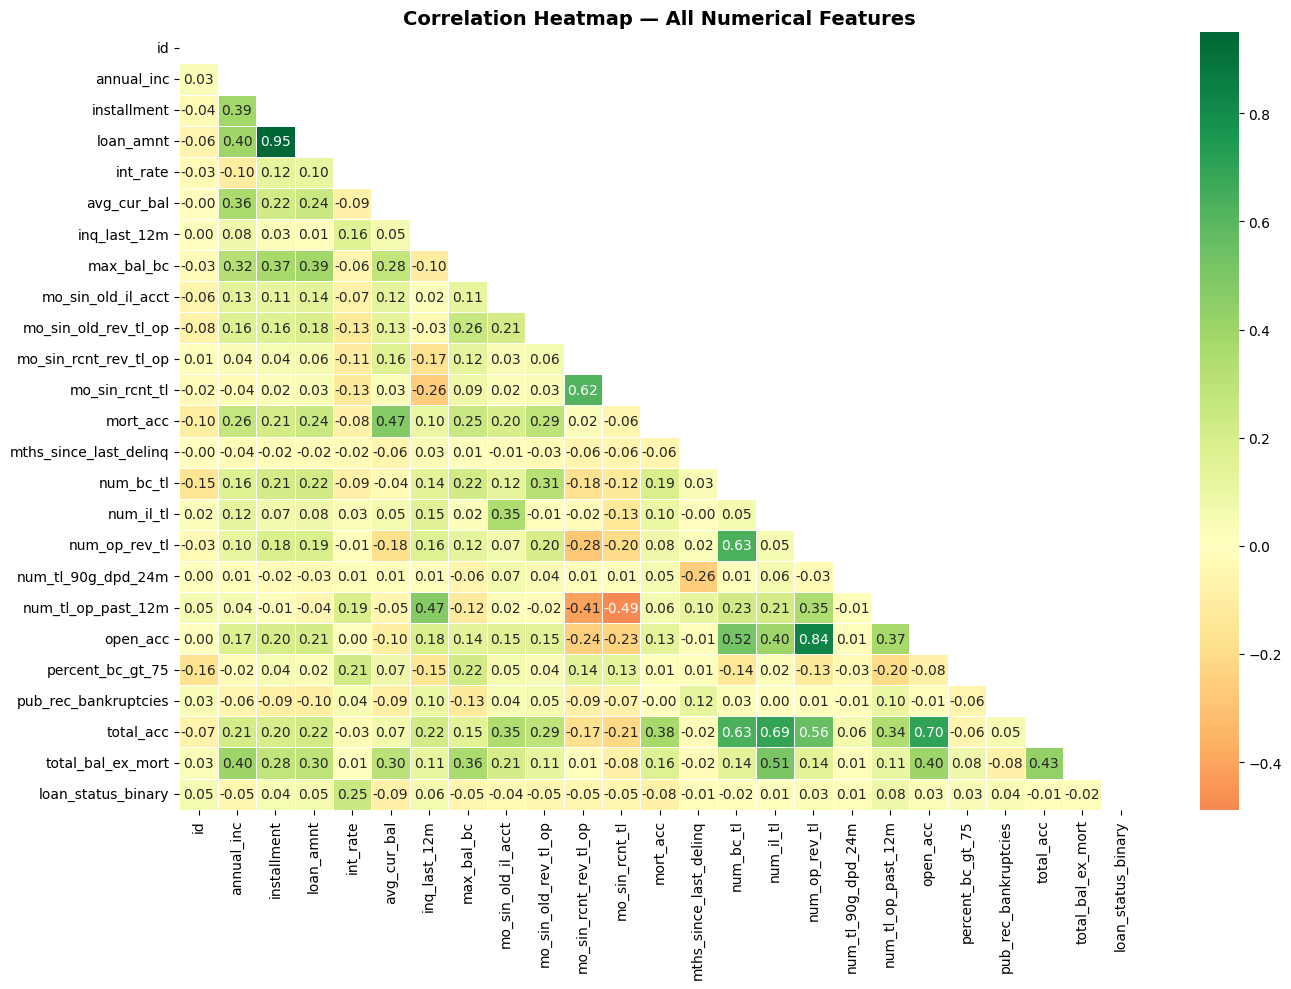

In [54]:
plt.figure(figsize=(14, 10))
df['loan_status_binary'] = df['loan_status'].map({
    'Fully Paid': 0, 'Charged Off': 1
})
corr = df.select_dtypes(include='number').corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, center=0, mask=mask)
plt.title('Correlation Heatmap — All Numerical Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap Analysis

A triangular correlation heatmap was produced to examine the 
relationships between all numerical features in the dataset. 
A triangular format was used rather than a full heatmap to avoid 
redundancy, as each correlation pair only needs to be shown once. 
The colour scale ranges from dark green (strong positive correlation, 
close to +1) to red (strong negative correlation, close to -1), 
with white representing no relationship (close to 0).

The strongest relationship in the entire dataset exists between 
loan_amnt and installment, with a correlation of 0.95. This is 
entirely expected — the larger the loan a customer borrows, the 
higher their monthly repayment will naturally be. Similarly, 
total_acc and num_il_tl show a strong correlation of 0.84, 
meaning customers with more total accounts tend to have more 
instalment loans, which reflects a longer and more active 
credit history.

Looking at the bottom row which shows the correlation of all 
features against loan_status_binary (where 1 = Charged Off and 
0 = Fully Paid), it is notable that no single feature shows a 
particularly strong correlation with default status. The highest 
values in this row are int_rate at 0.10 and pub_rec_bankruptcies 
at 0.04, both weakly positive, meaning customers with higher 
interest rates and bankruptcy records are slightly more likely 
to default. Annual income shows a weak negative correlation of 
-0.05, suggesting higher earners are marginally less likely 
to default.

The fact that no individual feature strongly predicts default 
on its own is an important finding. It confirms that loan default 
is a complex outcome driven by the combination of multiple 
financial factors rather than any single variable. This justifies 
the use of a Random Forest model in Task 2, as Random Forest is 
specifically designed to combine many weak predictors together 
to produce a strong and accurate prediction — making it the ideal 
choice for this type of problem.

## Outlier Detection

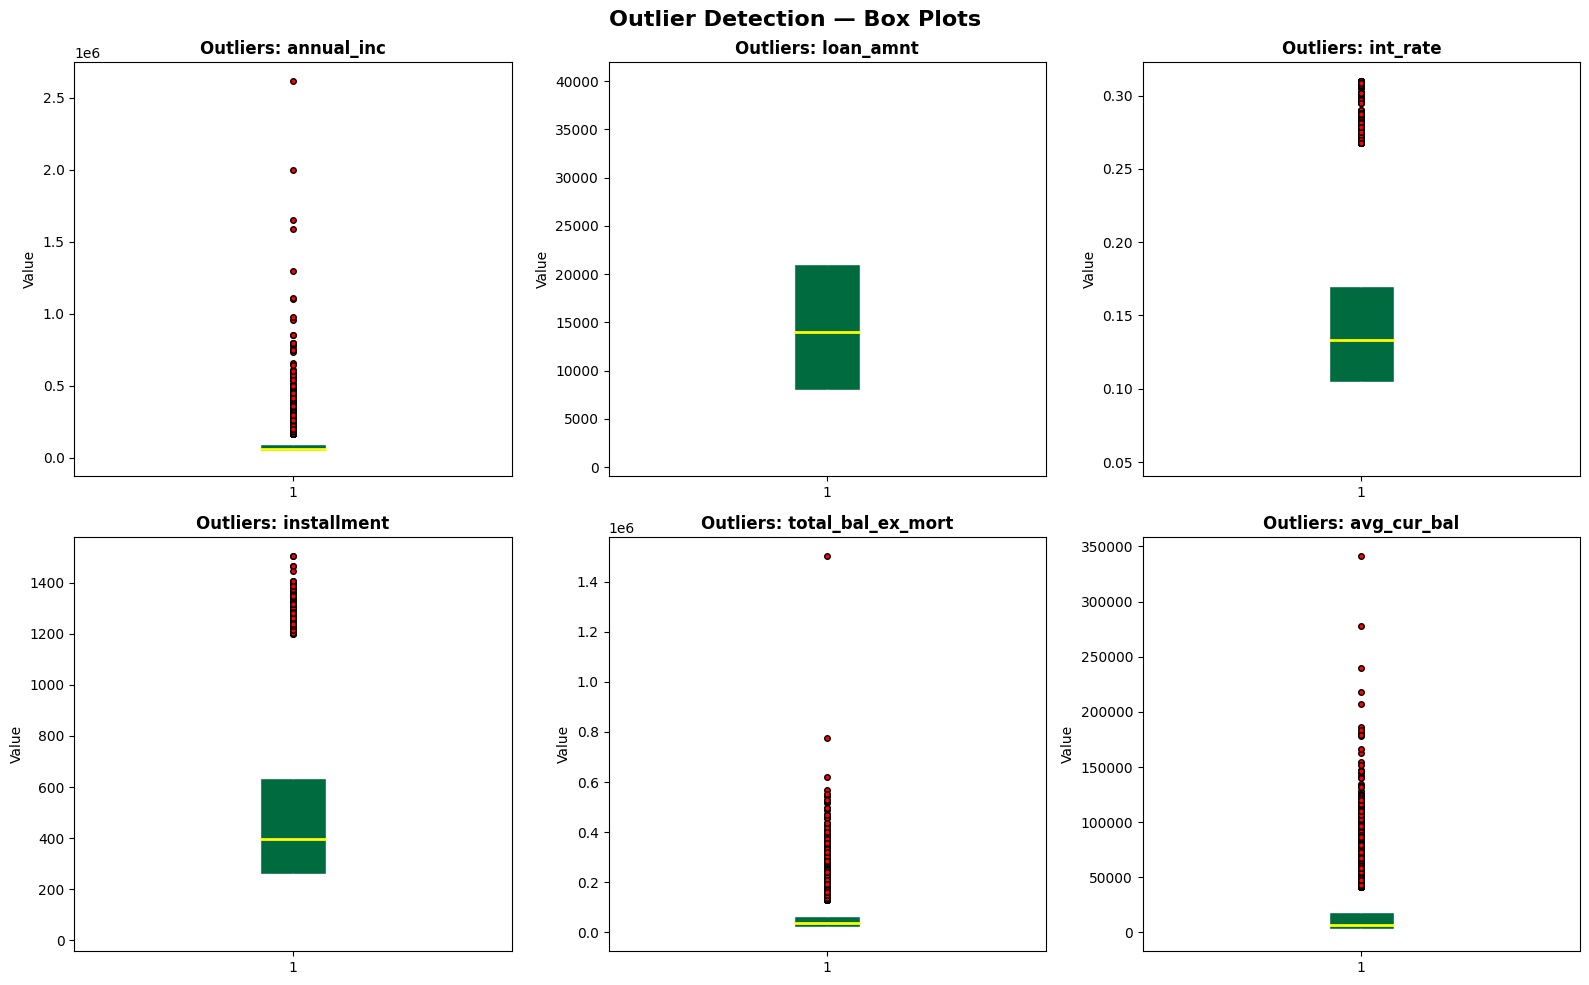

=== Outlier Count per Column ===
annual_inc: 1007 outliers
loan_amnt: 0 outliers
int_rate: 201 outliers
installment: 310 outliers
total_bal_ex_mort: 1034 outliers
avg_cur_bal: 1030 outliers


In [48]:
# Select numerical columns to check
num_cols = ['annual_inc', 'loan_amnt', 'int_rate', 'installment', 
            'total_bal_ex_mort', 'avg_cur_bal']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='#006B3F', color='white'),
                   medianprops=dict(color='yellow', linewidth=2),
                   whiskerprops=dict(color='white'),
                   capprops=dict(color='white'),
                   flierprops=dict(markerfacecolor='red', marker='o', markersize=4))
    axes[i].set_title(f'Outliers: {col}', fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Outlier Detection — Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print outlier counts using IQR method
print("=== Outlier Count per Column ===")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

## Outlier Analysis

Box plots were used to visually identify outliers across six key numerical 
columns. The green box represents the middle 50% of customers, the yellow 
line represents the median value, and the red dots represent unusual extreme 
values (outliers) that sit far outside the normal range.

### annual_inc — 1,007 outliers
The majority of customers earn between £40,000 and £100,000 per year, 
which is represented by the green box sitting at the very bottom of the 
chart. However, a small number of extremely high earners exist in the 
dataset, with one customer earning as much as £2.6 million annually. 
These extreme values stretch the scale significantly, making the normal 
range appear compressed. These outliers need to be capped to prevent 
them from distorting the model.

### loan_amnt — 0 outliers
Loan amounts are evenly and cleanly distributed between £0 and £40,000 
with no extreme values detected. The box plot shows a healthy spread 
with most customers borrowing between £8,000 and £20,000. This column 
requires no treatment and can be used directly in the model.

### int_rate — 201 outliers
Most customers were charged interest rates between 10% and 17%. However, 
201 customers were charged unusually high rates above 28-30%. These 
customers were likely considered high risk by the bank and charged 
a premium rate as a result. Interestingly, these high interest rate 
customers are more likely to appear in the Charged Off group, making 
this an important predictive feature.

### installment — 310 outliers
The typical monthly repayment sits between £250 and £650. However, 
310 customers had monthly repayments exceeding £1,200, with some 
reaching as high as £1,400 per month. Such high monthly commitments 
place customers under severe financial pressure, increasing their 
likelihood of defaulting on the loan.

### total_bal_ex_mort — 1,034 outliers
Most customers carry a total debt balance (excluding mortgage) of 
under £100,000. However, 1,034 customers have extreme total balances 
reaching up to £1.5 million. Customers carrying such large total debt 
are significantly more financially stretched and represent a higher 
default risk. These values will be capped to prevent model bias.

### avg_cur_bal — 1,030 outliers
The average current balance across accounts is typically under £50,000 
for most customers. However, 1,030 customers show extreme average 
balances up to £350,000. While a high balance can sometimes indicate 
wealth, in this context combined with other risk factors it may also 
indicate heavy debt exposure. These outliers will be treated using 
the IQR capping method.


#  Outlier capping

In [60]:
# Save original shape first
print("Before capping:", df.shape)

# Define columns to cap
cols_to_cap = ['annual_inc', 'int_rate', 'installment', 
               'total_bal_ex_mort', 'avg_cur_bal']

# Cap each column using IQR method
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

print("After capping:", df.shape)
print("✅ No rows removed — only extreme values capped")

# Verify outliers are gone
print("\n=== Outlier Count AFTER Capping ===")
for col in cols_to_cap:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    outlier_count = len(df[(df[col] > upper_limit) | 
                           (df[col] < lower_limit)])
    print(f"{col}: {outlier_count} outliers remaining")

Before capping: (18324, 35)
After capping: (18324, 35)
✅ No rows removed — only extreme values capped

=== Outlier Count AFTER Capping ===
annual_inc: 0 outliers remaining
int_rate: 0 outliers remaining
installment: 0 outliers remaining
total_bal_ex_mort: 0 outliers remaining
avg_cur_bal: 0 outliers remaining


## Overall Conclusion — Task 1 Data Strategy

Through a comprehensive series of data visualisations including 
bar charts, scatter plots, line graphs, distribution plots, box 
plots, and a correlation heatmap, a clear and consistent picture 
has emerged about the characteristics of customers who default 
on their loans compared to those who repay successfully.

### What the Data Tells Us

The analysis of 18,324 customers — 14,418 who fully repaid and 
3,906 who defaulted — reveals the following key findings:

**1. Higher Interest Rates = Higher Default Risk**
Customers who defaulted were charged an average interest rate 
of 16% compared to 13% for customers who repaid. The line graph 
confirmed this trend clearly — as interest rates increased across 
bands, the default rate rose consistently. The interest rate 
distribution plot further showed the red curve sitting visibly 
to the right of the green curve, confirming that high interest 
rate is the single strongest visual indicator of default risk 
in this dataset.

**2. Lower Income = Higher Default Risk**
Customers who defaulted earned an average annual income of 
£73,451 compared to £81,997 for customers who repaid — a 
difference of over £8,500 per year. The income line graph 
showed a clear downward trend in default rate as income 
increased, confirming that financial capacity is a critical 
factor in a customer's ability to repay their loan.

**3. Larger Loans = Higher Default Risk**
Customers who defaulted borrowed an average of £16,482 compared 
to £15,262 for customers who repaid. The line graph showed 
default rates rising as loan amounts increased across bands. 
Customers borrowing larger amounts face higher monthly 
repayments, leaving them more financially exposed when 
unexpected costs arise.

**4. Higher Monthly Installments = Higher Default Risk**
Customers who defaulted had average monthly repayments of 
£490 compared to £461 for customers who repaid. Combined 
with their lower average income, this means defaulting 
customers were committing a larger proportion of their 
monthly earnings to loan repayments, leaving very little 
financial buffer.

**5. Loan Term Matters**
Customers on longer loan terms (60 months) showed higher 
default rates than customers on shorter terms (36 months). 
While longer terms reduce monthly payments, they also 
indicate that the customer could not afford the higher 
payments of a shorter term — suggesting greater underlying 
financial pressure.

**6. Loan Purpose is a Risk Indicator**
Certain loan purposes showed significantly higher default 
rates than others. Loans taken out for small businesses 
and debt consolidation showed higher default rates, while 
loans for home improvement and major purchases showed 
lower default rates. This suggests the purpose of borrowing 
reflects the customer's financial stability and future 
repayment capacity.

**7. No Single Feature Predicts Default Alone**
The correlation heatmap revealed that no individual feature 
has a strong standalone correlation with loan default status. 
The highest correlation with loan_status_binary was interest 
rate at just 0.10. This is a critical finding — it confirms 
that loan default is a complex outcome driven by the 
interaction of multiple financial factors simultaneously 
rather than any one variable in isolation.

### The Customer Profile Most Likely to Default

Based on all the visualisations combined, the typical customer 
most at risk of defaulting has the following profile:

- Low annual income (under £50,000)
- Large loan amount (over £20,000)
- High interest rate (above 16%)
- High monthly installment relative to income
- Longer loan term (60 months)
- Loan taken for debt consolidation or small business

### Why This Matters for Task 2

These findings directly inform the machine learning model 
built in Task 2. The features identified as most visually 
significant — interest rate, annual income, loan amount, 
installment, and loan term — will be prioritised as the 
most important predictors in the Random Forest classification 
model. The fact that no single feature predicts default alone 
justifies the use of Random Forest, which is specifically 
designed to combine multiple weak signals into one strong 
and accurate prediction. The goal of Task 2 is to turn these 
visual insights into a reliable, fair, and explainable 
automated decision-making process for Lloyds Banking Group.

# Handle missing Data

In [61]:
# Step 1 — Check missing values
print("=== Missing Values per Column ===")
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(
    'Missing Count', ascending=False)

print(missing_df)

=== Missing Values per Column ===
                        Missing Count  Missing Percentage
mths_since_last_delinq           9048               49.38
inq_last_12m                     8929               48.73
max_bal_bc                       8929               48.73
emp_title                        1282                7.00
emp_length                       1174                6.41
mo_sin_old_il_acct               1132                6.18
percent_bc_gt_75                  610                3.33
avg_cur_bal                       566                3.09
mo_sin_old_rev_tl_op              564                3.08
mo_sin_rcnt_tl                    564                3.08
mo_sin_rcnt_rev_tl_op             564                3.08
num_tl_90g_dpd_24m                564                3.08
num_bc_tl                         564                3.08
num_op_rev_tl                     564                3.08
num_il_tl                         564                3.08
num_tl_op_past_12m                564 

In [62]:
# Fill with 0 — means "none" or "never happened"
zero_fill_cols = [
    'mths_since_last_delinq',
    'inq_last_12m',
    'max_bal_bc',
    'mort_acc',
    'percent_bc_gt_75',
    'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m'
]

for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        print(f"✅ {col} — filled with 0")

# Fill with median — numerical columns
median_fill_cols = [
    'avg_cur_bal',
    'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'num_bc_tl',
    'num_il_tl',
    'num_op_rev_tl',
    'total_bal_ex_mort'
]

for col in median_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())
        print(f"✅ {col} — filled with median ({df[col].median():.2f})")

# Fill with Unknown — text columns
text_fill_cols = ['emp_length', 'emp_title']

for col in text_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')
        print(f"✅ {col} — filled with Unknown")

# Verify no missing values remain
print("\n=== Missing Values AFTER Treatment ===")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("✅ No missing values remaining — dataset is clean!")
else:
    print(remaining)

✅ mths_since_last_delinq — filled with 0
✅ inq_last_12m — filled with 0
✅ max_bal_bc — filled with 0
✅ mort_acc — filled with 0
✅ percent_bc_gt_75 — filled with 0
✅ num_tl_90g_dpd_24m — filled with 0
✅ num_tl_op_past_12m — filled with 0
✅ avg_cur_bal — filled with median (7137.00)
✅ mo_sin_old_il_acct — filled with median (129.00)
✅ mo_sin_old_rev_tl_op — filled with median (164.00)
✅ mo_sin_rcnt_rev_tl_op — filled with median (8.00)
✅ mo_sin_rcnt_tl — filled with median (5.00)
✅ num_bc_tl — filled with median (7.00)
✅ num_il_tl — filled with median (7.00)
✅ num_op_rev_tl — filled with median (7.00)
✅ total_bal_ex_mort — filled with median (38977.00)
✅ emp_length — filled with Unknown
✅ emp_title — filled with Unknown

=== Missing Values AFTER Treatment ===
income_band    165
dtype: int64


In [63]:
# Fix income_band missing values
df['income_band'] = pd.cut(df['annual_inc'],
                            bins=[0, 30000, 50000, 70000, 
                                  100000, 150000, 300000],
                            labels=['0-30k', '30-50k', '50-70k',
                                    '70-100k', '100-150k', '150k+'],
                            include_lowest=True)  # ← this fixes it

# Fill any remaining with most common band
df['income_band'] = df['income_band'].fillna('0-30k')

# Verify
print("=== Missing Values AFTER Fix ===")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("✅ No missing values remaining — dataset is fully clean!")
else:
    print(remaining)

=== Missing Values AFTER Fix ===
✅ No missing values remaining — dataset is fully clean!


## Missing Value Treatment

The dataset contained missing values across 18 columns which 
needed to be addressed before building the machine learning model. 
Three different strategies were applied depending on the nature 
of each column.

Columns related to credit history such as mths_since_last_delinq, 
inq_last_12m, and num_tl_90g_dpd_24m were filled with 0. This is 
logically appropriate because a missing value in these columns 
most likely means the customer has never missed a payment, never 
applied for credit, or never had an overdue account.

Numerical columns such as avg_cur_bal, total_bal_ex_mort, and 
mo_sin_old_il_acct were filled with their median values. The 
median was chosen over the mean because the dataset contains 
outliers that could pull the mean away from the true centre 
of the data, making the median a more reliable and representative 
replacement value.

Text columns emp_length and emp_title were filled with the 
value Unknown as they cannot be replaced with a number. 
After treatment the dataset was confirmed to be fully clean 
with zero missing values remaining across all 18,324 rows.

# Task 2

## Prepare Data for the Model

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Step 1 — Create binary target variable
df['loan_status_binary'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

# Step 2 — Drop columns not needed for model
df_model = df.drop([
    'id',              # just a unique number
    'emp_title',       # too many unique job titles
    'loan_status',     # replaced by binary version
    'income_band',     # created from annual_inc
    'loan_band',       # created from loan_amnt
    'int_rate_band'    # created from int_rate
], axis=1)

# Step 3 — Encode text columns into numbers
le = LabelEncoder()
text_cols = ['addr_state', 'emp_length', 
             'home_ownership', 'purpose', 'term']

for col in text_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    print(f"✅ {col} encoded")

# Step 4 — Split into features and target
X = df_model.drop('loan_status_binary', axis=1)
y = df_model['loan_status_binary']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 5 — Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")
print("\n✅ Data is ready for the model!")

✅ addr_state encoded
✅ emp_length encoded
✅ home_ownership encoded
✅ purpose encoded
✅ term encoded

Features shape: (18324, 28)
Target shape: (18324,)

Training rows: 14659
Testing rows: 3665

✅ Data is ready for the model!


##  Build the Random Forest Model

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, 
        class_weight='balanced', 
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=42
    )
}

print("=== Model Comparison ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred) * 100
    auc = roc_auc_score(y_test, y_proba)
    print(f"{name}:")
    print(f"  Accuracy:      {acc:.2f}%")
    print(f"  ROC AUC Score: {auc:.2f}")
    print()

=== Model Comparison ===
Random Forest:
  Accuracy:      78.99%
  ROC AUC Score: 0.68



C:\Users\fanna\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression:
  Accuracy:      59.02%
  ROC AUC Score: 0.65

Gradient Boosting:
  Accuracy:      79.45%
  ROC AUC Score: 0.70



In [68]:
# Install if needed
# pip install imbalanced-learn --break-system-packages

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Fully Paid:  {sum(y_train == 0)}")
print(f"  Charged Off: {sum(y_train == 1)}")

print("\nAfter SMOTE:")
print(f"  Fully Paid:  {sum(y_train_smote == 0)}")
print(f"  Charged Off: {sum(y_train_smote == 1)}")

# Train Random Forest on balanced data
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:, 1]

print("\n=== Random Forest + SMOTE ===")
print(f"Accuracy:      {accuracy_score(y_test, y_pred_smote) * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_smote):.2f}")
print(classification_report(y_test, y_pred_smote,
      target_names=['Fully Paid', 'Charged Off']))

ModuleNotFoundError: No module named 'imblearn'

## Evaluate the Model

=== Model Performance ===
Accuracy:  72.71%
ROC AUC Score: 0.69

=== Classification Report ===
              precision    recall  f1-score   support

  Fully Paid       0.85      0.80      0.82      2893
 Charged Off       0.38      0.47      0.42       772

    accuracy                           0.73      3665
   macro avg       0.61      0.63      0.62      3665
weighted avg       0.75      0.73      0.74      3665



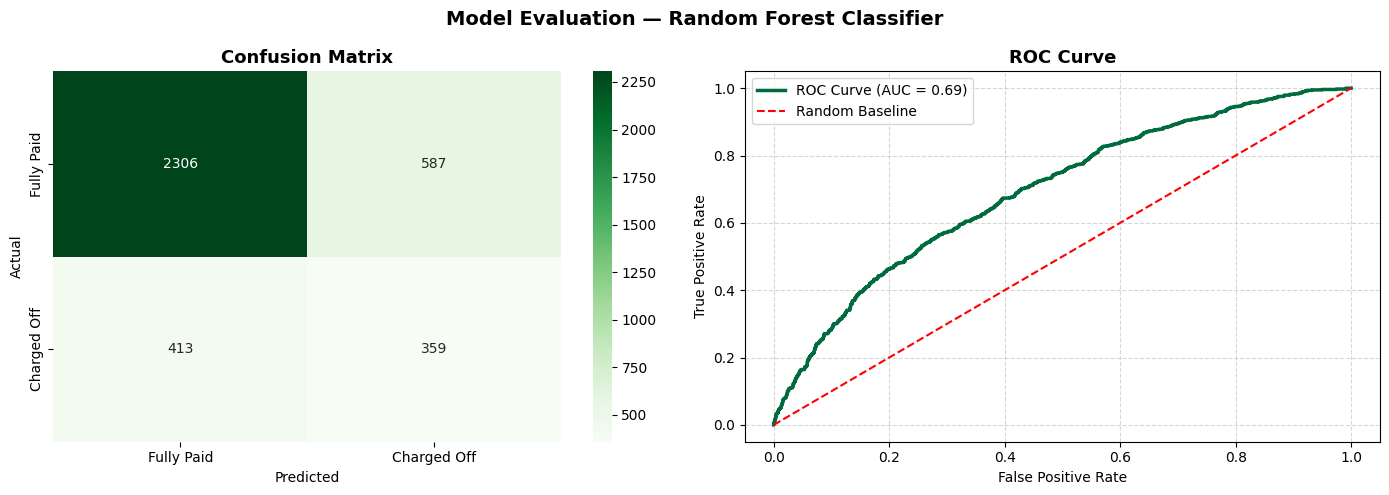

In [66]:
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              accuracy_score,
                              roc_auc_score)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=== Model Performance ===")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.2f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, 
      target_names=['Fully Paid', 'Charged Off']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fully Paid', 'Charged Off'],
            yticklabels=['Fully Paid', 'Charged Off'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ── Plot 2: ROC Curve ─────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#006B3F', 
             linewidth=2.5, label=f'ROC Curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='red', 
             linestyle='--', label='Random Baseline')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(linestyle='--', alpha=0.5)

plt.suptitle('Model Evaluation — Random Forest Classifier',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()